# CLO DUAL JSON MAKER COVER ARC DATA 
Centerpoint 기준으로 arrangement point하지 않고

각 패널의 Mean Point를 기준으로 arrangement point 생성

++ 추가적으로 ARC 2 Bezier data에 대해서도 다룰 수 있게 됨.ㅋ.ㅋ

In [1]:
import os, sys
sys.path.append(os.path.dirname(os.getcwd()))
from glob import glob
import math
from pprint import pprint
import torch

import pygarment as pyg
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time

from tqdm import tqdm
import json
import random

import trimesh
from ANALYSIS.analysis_utils import (
    plot_panel_info,
    visualize_meshes_plotly,
    v_id_map
)



In [2]:
import pandas as pd
from svgpathtools import Path, Line, QuadraticBezier, CubicBezier, Arc
import os
import random
import string
import json

def load_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

def euler_angles_to_rotation_matrix(euler_angles):
    """
    Convert Euler angles to a rotation matrix.
    
    Parameters:
    euler_angles (tuple or list): A tuple or list of three angles (roll, pitch, yaw) in radians.
    
    Returns:
    np.ndarray: A 3x3 rotation matrix.
    """
    roll, pitch, yaw = euler_angles

    # Compute individual rotation matrices
    R_x = np.array([
        [1, 0, 0],
        [0, np.cos(roll), -np.sin(roll)],
        [0, np.sin(roll), np.cos(roll)]
    ])

    R_y = np.array([
        [np.cos(pitch), 0, np.sin(pitch)],
        [0, 1, 0],
        [-np.sin(pitch), 0, np.cos(pitch)]
    ])

    R_z = np.array([
        [np.cos(yaw), -np.sin(yaw), 0],
        [np.sin(yaw), np.cos(yaw), 0],
        [0, 0, 1]
    ])

    # Combine the rotation matrices
    R = np.dot(R_z, np.dot(R_y, R_x))

    return R

def rotation_matrix_2d(euler_am):
    """
    Convert an angle in radians to a 2D rotation matrix.
    
    Parameters:
    theta (float): The rotation angle in radians.
    
    Returns:
    np.ndarray: A 2x2 rotation matrix.
    """
    c = np.cos(euler_am)
    s = np.sin(euler_am)
    
    R = np.array([
        [c, -s],
        [s,  c]
    ])
    
    return R

def rotate_point(x, y, theta):
    """
    Rotate a 2D point (x, y) by an angle theta.
    
    Parameters:
    x (float): Original x-coordinate.
    y (float): Original y-coordinate.
    theta (float): Rotation angle in radians.
    
    Returns:
    (float, float): Rotated (x', y') coordinates.
    """
    R = rotation_matrix_2d(theta)  # 회전 행렬 계산
    rotated = R @ np.array([x, y]) # 행렬 곱 수행
    
    return rotated[0], rotated[1]  # 변환된 좌표 반환


def calculate_center_point(panel_name, spec, panel_svg_path_dict):
    vertices_from_spec = np.asarray(spec['pattern']['panels'][panel_name]['vertices'])    
    offset = np.min(vertices_from_spec * np.array([1, -1]), axis=0)

    euler_angles = spec['pattern']['panels'][panel_name]['rotation']
    translation = spec['pattern']['panels'][panel_name]['translation']
    rotation_matrix = euler_angles_to_rotation_matrix(euler_angles)

    path = panel_svg_path_dict[panel_name][0]
    
    x1, x2, y1, y2 = path.bbox()
    xm = (x1 + x2) / 2
    ym = (y1 + y2) / 2 
    
    bbox_center = np.array([xm, ym])
    bbox_center = (bbox_center + offset) * np.array([1, -1])
    
    batch_point = np.array([
        bbox_center[0], bbox_center[1], 1
    ]) @ rotation_matrix.T + translation
    #print(panel_name, batch_point) 
    return batch_point.reshape(1, -1)
    # batch_point_list.append(batch_point.reshape(1, -1))

def  matching_point(target_point):
# 모든 batch_point들과 target_point 간의 거리(L2 norm) 계산
    keys = list(batch_points.keys())  # batch_point의 key 목록
    values = np.array(list(batch_points.values()))  # value를 numpy 배열로 변환

    # L2 거리 계산 (유클리드 거리)
    distances = np.linalg.norm(values - target_point, axis=1)

    # 가장 가까운 key 찾기
    closest_index = np.argmin(distances)  # 최소 거리의 인덱스
    closest_key = keys[closest_index]  # 해당 인덱스의 key 가져오기

    #print(f"가장 가까운 batch_point: {closest_key}")
    
    return closest_key    

def process_path_data(data):

    rows = []
    # Path 내부 요소 순회
    for element in data[0]:
        row = {
            "type": type(element).__name__,  # 요소 타입
            "start": getattr(element, "start", None),
            "controla": getattr(element, "control", None),
            "controlb": getattr(element, "control", None),
            "control1": getattr(element, "control1", None),
            "control2": getattr(element, "control2", None),
            "end": getattr(element, "end", None),
            "radius": getattr(element, "radius", None),
            "rotation": getattr(element, "rotation", None),
            "large_arc": getattr(element, "large_arc", None),
            "sweep": getattr(element, "sweep", None),
        }
        rows.append(row)
    
    # DataFrame 생성
    df = pd.DataFrame(rows)
    
    # type 열의 값을 변경하기 위한 매핑 사전
    type_mapping = {
        "QuadraticBezier": "Bezier Curve",
        "CubicBezier": "Bezier Curve",
        "Line": "Straight",
        "Arc": "Arc", #임의로 바꿈    
    }
    
    # type 열 값 변경
    df["type"] = df["type"].map(type_mapping).fillna(df["type"])
    
    # TODO: 2024.01.16 이후 Arc에 대한 정보에 대해 Bezier Curve로 변환예정.
    # -> 일단 되게 끔 하는게 목표.
    # 대상 열 목록
    coordinate_columns = ["start",  "controla", "controlb", "control1", "control2",  "end"] 
    ### 여기서 ARC 데이터 처리를 해줘야함.
    
    # 실수부와 허수부를 분리하여 새로운 열로 추가하는 함수
    def extract_coordinates(df, columns):
        for col in columns:
            df[f"{col}_x"] = df[col].apply(lambda z: z.real if isinstance(z, complex) else None)
            df[f"{col}_y"] = df[col].apply(lambda z: z.imag if isinstance(z, complex) else None)
        # TODO: x, y 좌표를 상하 반전
        # minimize
        max_y = df[['start_y', 'controla_y', 'controlb_y', 'control1_y', 'control2_y', 'end_y']].max().max()
        min_y = df[['start_y', 'controla_y', 'controlb_y', 'control1_y', 'control2_y', 'end_y']].min().min()
        stand_y = (max_y + min_y)
        #잠만대기기기한부분 20250208
        for col in columns: 
            df[f"{col}_y"] = (stand_y - df[f"{col}_y"]) * (8.5) #TODO: 01.17 scaling까지 
            df[f"{col}_x"] = df[f"{col}_x"] * (8.5)#TODO: scaling까지 
        df['controlb_x'] = df['controla_x'].round(4) # TODO: ontrolb_x 에 round
        df[f"radius"] = df[f"radius"] * (8.5)
        #TODO: 여기까지
        return df
    
    # 실수부와 허수부를 분리하여 데이터프레임에 추가
    df = extract_coordinates(df, coordinate_columns)
    
    # 기존 열 중 복소수 값을 제거
    df = df.drop(columns=coordinate_columns)
    
    return df

def calculate_edge_length(edge):
    """
    각 엣지의 길이를 계산. QuadraticBezier의 경우 CubicBezier처럼 처리. 
    """
    if isinstance(edge, Line):
        return abs(edge.end - edge.start)
    elif isinstance(edge, QuadraticBezier):
        # QuadraticBezier -> CubicBezier 변환
        # 기존 컨트롤 포인트
        control1 = edge.control
        
        # 새로운 컨트롤 포인트 추가
        control2 = complex(round(control1.real, 4), control1.imag)  # x좌표 소수점 4자리로 변경
        # QuadraticBezier -> CubicBezier 변환
        cubic_edge = CubicBezier(
            start=edge.start,
            control1=control1,
            control2=control2,
            end=edge.end
        )
        # CubicBezier 길이 계산
        return cubic_edge.length()
    elif isinstance(edge, CubicBezier):
        return edge.length()
    elif isinstance(edge, Arc):
        return edge.length()
    else:
        raise ValueError(f"Unsupported edge type: {type(edge)}")

def calculate_fstart_fend(path, panel_name):
    """
    전체 엣지에 대해 fstart와 fend를 계산.
    """
    total_length = sum(calculate_edge_length(edge) for edge in path)
    fstart = 0.0
    results = []

    for idx, edge in enumerate(path):  # enumerate를 사용하여 번호 부여
        edge_length = calculate_edge_length(edge) # TODO: name 넣어봄 01.19.17:00
        fend = fstart + (edge_length / total_length)
        results.append({
            "edge_id": idx,  # 엣지 번호
            "edge": str(edge),  # Edge를 문자열로 변환하여 저장
            "fstart": round(fstart, 6),
            "fend": round(fend, 6)
        })
        fstart = fend

    return results

# 패널 이름에 따라 데이터프레임 처리
def process_negative_columns(panel_names, panel_dataframes):
    # 패널 이름이 '_back', '_b', '_btorso'로 끝나는 경우
    if '_back' in panel_names or '_b' in panel_names or '_btorso' in panel_names or "_b_l" in panel_names or "_b_r" in panel_names:
        #print(f"Processing panel: {panel_names}")  # 디버깅 출력
        # 해당 데이터프레임의 '_x'로 끝나는 열 처리
        df = panel_dataframes
        df_columns = df.columns  # 데이터프레임 열 이름 가져오기
        

        # TODO: 20240123 15:30 그냥 해봄            
        for col in df_columns:
            if col.endswith('_x'):  # '_x'로 끝나는 열 확인
                # df[col] = stand_x - df[col]
                df[col] = df[col] * -1  # 열 값에 음수 곱하기
                # print(df[col])
    else:
        #print(f"Skipping panel: {panel_names}")
        pass
    return panel_dataframes

def convert_stitch_dict(stitch_dict_info, panel_index_mapping_info):
    new_stitch_dict = {}

    for key, value in stitch_dict_info.items():
        filtered_list = []
        for stitch in value:
            if isinstance(stitch, dict) and 'panel' in stitch and 'edge' in stitch:
                filtered_list.append({
                    'panel': panel_index_mapping_info[stitch['panel']],
                    'edge': stitch['edge']
                })
            else:
                # dict가 아니거나 panel/edge 키가 없으면 무시
                pass

        new_stitch_dict[key] = filtered_list

    value_stack = []
    for value in new_stitch_dict.values():
        # dictionary stack
        for value in value:
            value_stack.append(value)     
    return value_stack

# 통합할때 추가하는 방법. (2024.02.04 작성)
def unify_clo_json_data(Clo_json_path, Clo_json_path_to_add):
    with open(Clo_json_path, 'r') as file:
        json_data = json.load(file)
    with open(Clo_json_path_to_add, 'r') as file:
        json_data_to_add = json.load(file)
    
    # FabricList, GradingRuleTableList(제껴도됨), PatternList, SymmetricDataList(제껴도됨), InstanceDataList, SeamLinePairGroupList
    # 통합할때 추가하는 방법.
    # Fabric의 경우
    json_data['FabricList'].append(json_data_to_add['FabricList'][0])
    # Pattern의 경우
    [json_data['PatternList'].append(json_data_to_add['PatternList'][num]) for num in range(len(json_data_to_add['PatternList']))]
    # InstanceDataList의 경우
    [json_data['InstanceDataList'].append(json_data_to_add['InstanceDataList'][num]) for num in range(len(json_data_to_add['InstanceDataList']))]
    # SeamLinePairGroupList의 경우
    [json_data['SeamLinePairGroupList'].append(json_data_to_add['SeamLinePairGroupList'][num]) for num in range(len(json_data_to_add['SeamLinePairGroupList']))]
    
    return json_data
# 통합된 STITCH 추가하는 방법. (2024.02.04 작성)
def stitch_data_unify(Clo_stitch_path, Clo_stitch_path_to_add):
    with open(Clo_stitch_path, "r") as f:
        stitch_data_1 = json.load(f)
    #stitch_data_1
    with open(Clo_stitch_path_to_add, "r") as f:
        stitch_data_2 = json.load(f)
    
    max_panel_1 = max(d["panel"] for d in stitch_data_1)
    offset = max_panel_1 + 1
    for item in stitch_data_2:
        item["panel"] += offset
    garment_first_id = os.path.basename(os.path.dirname(Clo_stitch_path))
    garment_second_id = os.path.basename(os.path.dirname(Clo_stitch_path_to_add))

    return (stitch_data_1+stitch_data_2), [garment_first_id, garment_second_id]

# Unique UUID 생성
def get_unique_random_string(existing_set):
    
    while True:
        # 영문(대소문자) + 숫자
        candidate = ''.join(random.choices(string.ascii_letters + string.digits, k=6))
        # 중복 검사
        if candidate not in existing_set:
            existing_set.add(candidate)
            return candidate
    

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

def svg_arc_to_center(x1, y1, x2, y2, rx, ry, phi, large_arc, sweep):
    """
    SVG의 endpoint-to-center 변환 알고리즘(회전 phi 포함)을 수행합니다.
    여기서는 phi가 0라고 가정할 수 있으므로, cos(phi)=1, sin(phi)=0를 사용합니다.
    
    반환: (cx, cy, theta_start, theta_end, delta_theta)
    """

    # phi (회전각)을 라디안으로
    phi_rad = math.radians(phi)
    
    # Step 1: 중간점과 변환된 좌표 (phi=0이면 그대로)
    dx = (x1 - x2) / 2.0
    dy = (y1 - y2) / 2.0
    # x1', y1'
    x1p = math.cos(phi_rad)*dx + math.sin(phi_rad)*dy
    y1p = -math.sin(phi_rad)*dx + math.cos(phi_rad)*dy
    
    # Step 2: rx,ry 스케일링 체크 (여기서는 필요 없으리라 가정)
    lam = (x1p**2)/(rx**2) + (y1p**2)/(ry**2)
    if lam > 1:
        scale = math.sqrt(lam)
        rx *= scale
        ry *= scale

    # Step 3: 계수 (SVG 사양에 따른)
    num = rx**2 * ry**2 - rx**2 * y1p**2 - ry**2 * x1p**2
    den = rx**2 * y1p**2 + ry**2 * x1p**2
    # 부동소수점 오차로 음수 방지
    factor = math.sqrt(max(0, num/den)) if den != 0 else 0
    # SVG 사양에 따라, large_arc와 sweep 플래그가 같으면 부호 반전

    if large_arc == sweep:
        factor = -factor
    

    # if sweep == True:
    #     sweep = False
    # else:
    #     sweep = True    
        
    cxp = factor * (rx * y1p / ry)
    cyp = factor * (-ry * x1p / rx)

    # Step 4: 원래 좌표계로 복원 (phi=0이면 회전 없이 중간점에 더함)
    mid_x = (x1 + x2) / 2.0
    mid_y = (y1 + y2) / 2.0
    cx = math.cos(phi_rad)*cxp - math.sin(phi_rad)*cyp + mid_x
    cy = math.sin(phi_rad)*cxp + math.cos(phi_rad)*cyp + mid_y

    # Step 5: 시작각과 끝각 (원 중심 기준)
    theta_start = math.atan2(y1 - cy, x1 - cx)
    theta_end   = math.atan2(y2 - cy, x2 - cx)
    
    # Step 6: 아크의 진행각 delta_theta 결정 (SVG 사양)
    delta_theta = theta_end - theta_start
    if sweep:
        if delta_theta < 0:
            delta_theta += 2*math.pi
    else:
        if delta_theta > 0:
            delta_theta -= 2*math.pi
    
    # 대개 추가 보정은 필요하나, 여기서는 플래그에 따른 delta_theta만 사용
    return cx, cy, theta_start, theta_end, delta_theta

def reflect_two_points_across_line(P0, P1, P2, P3):
    """
    직선 P0-P3에 대해,
    점 P1과 P2를 '동시에' 대칭시킨 (P1', P2')를 반환한다.
    
    각 인자는 (x, y) 형태의 튜플 또는 리스트라고 가정.
    """
    P0 = np.array(P0, dtype=float)    
    P1 = np.array(P1, dtype=float)
    P2 = np.array(P2, dtype=float)
    P3 = np.array(P3, dtype=float)
    # 직선 방향벡터
    v = P3 - P0
    # 내적 (v·v)
    vdotv = v.dot(v)
    
    # 만약 P0와 P3가 같다면 반사 불가능 → 그냥 원래 점 반환하거나 예외 처리
    if abs(vdotv) < 1e-15:
        return (tuple(P1), tuple(P2))
    
    # ---- P1 대칭 ----
    w1 = P1 - P0
    w1dotv = w1.dot(v)
    w1_proj = (w1dotv / vdotv) * v
    w1_prime = 2 * w1_proj - w1
    P1_reflected = P0 + w1_prime  # P1'
    
    # ---- P2 대칭 ----
    w2 = P2 - P0
    w2dotv = w2.dot(v)
    w2_proj = (w2dotv / vdotv) * v
    w2_prime = 2 * w2_proj - w2
    P2_reflected = P0 + w2_prime  # P2'
    
    return tuple(P1_reflected), tuple(P2_reflected)

def single_arc_to_cubic_bezier(x1, y1, x2, y2, rx, ry, rotation, large_arc, sweep):
    """
    주어진 ARC 정보를 기반으로 단일 Cubic Bézier 곡선으로 근사합니다.
    회전(rotation)은 도 단위이며, 여기서는 rotation=0가 주어졌습니다.
    
    반환: (P0, P1, P2, P3), 그리고 (cx, cy, theta_start, theta_end, delta_theta)
    """
    #이렇게하면 뒤만 이상해짐
    # if sweep == True:
    #     sweep = False
    # else:
    #     sweep = True
        
    cx, cy, theta_start, theta_end, delta_theta = svg_arc_to_center(x1, y1, x2, y2, rx, ry, rotation, large_arc, sweep)
    
    # 엔드포인트들
    P0 = (cx + rx * math.cos(theta_start), cy + ry * math.sin(theta_start))
    P3 = (cx + rx * math.cos(theta_end),   cy + ry * math.sin(theta_end))
    
    # Cubic Bézier 공식: k = (4/3)*tan(delta_theta/4)
    k = (4.0/3.0) * math.tan(delta_theta/4.0)
    
    # 컨트롤 포인트
    P1 = (P0[0] - k * rx * math.sin(theta_start),
          P0[1] + k * ry * math.cos(theta_start))
    P2 = (P3[0] + k * rx * math.sin(theta_end),
          P3[1] - k * ry * math.cos(theta_end))
    
    #P1_inverse, P2_inverse = reflect_two_points_across_line(P0, P1, P2, P3)
    return (P0, P1, P2, P3)

# --------------------------------------------------------------------
# 주어진 ARC 정보
# Arc(start=(13.019250000000005+0j), radius=(13.896131794946111+13.896131794946111j),
#     rotation=0, large_arc=False, sweep=False, end=(23.83805+5.175120074823674j))






In [6]:
batch_points = {
"Arm_Back_1_L" : [ 20.4240,  132.30371, -15.25501],
"Arm_Back_2_L" : [ 25.4240,  127.80371, -15.25501],
"Arm_Back_3_L" : [ 30.4240,  123.30371, -15.25501],
"Arm_Back_4_L" : [ 35.4240,  118.80371, -15.25501],
"Arm_Back_5_L" : [ 40.4240,  114.30371, -15.25501],
"Arm_Back_6_L" : [ 45.4240,  109.80371, -15.25501],
"Arm_Back_7_L" : [ 50.4240,  105.30371, -15.25501],
"Arm_Back_8_L" : [ 55.4240,  100.80371, -15.25501],
"Arm_Back_1_R" : [ -20.4240,  132.30371, -15.25501],
"Arm_Back_2_R" : [ -25.4240,  127.80371, -15.25501],
"Arm_Back_3_R" : [ -30.4240,  123.30371, -15.25501],
"Arm_Back_4_R" : [ -35.4240,  118.80371, -15.25501],
"Arm_Back_5_R" : [ -40.4240,  114.30371, -15.25501],
"Arm_Back_6_R" : [ -45.4240,  109.80371, -15.25501],
"Arm_Back_7_R" : [ -50.4240,  105.30371, -15.25501],
"Arm_Back_8_R" : [ -55.4240,  100.80371, -15.25501],
# Mid 일단 안씀.
# "Arm_Mid_1_L" :  [ 20.4240,  138.30371, -1.300],
# "Arm_Mid_2_L" :  [ 25.4240,  133.80371, -1.000],
# "Arm_Mid_3_L" :  [ 30.4240,  129.30371, -0.7000],
# "Arm_Mid_4_L" :  [ 35.4240,  124.80371, -0.4000],
# "Arm_Mid_5_L" :  [ 40.4240,  120.30371, -0.1000],
# "Arm_Mid_6_L" :  [ 45.4240,  115.80371,  0.2000],
# "Arm_Mid_7_L" :  [ 50.4240,  111.30371,  0.5000],
# "Arm_Mid_8_L" :  [ 55.4240,  106.80371,  0.8000],
# "Arm_Mid_1_R" : [ -20.4240,  138.30371, -1.300],
# "Arm_Mid_2_R" : [ -25.4240,  133.80371, -1.000],
# "Arm_Mid_3_R" : [ -30.4240,  129.30371, -0.7000],
# "Arm_Mid_4_R" : [ -35.4240,  124.80371, -0.4000],
# "Arm_Mid_5_R" : [ -40.4240,  120.30371, -0.1000],
# "Arm_Mid_6_R" : [ -45.4240,  115.80371,  0.2000],
# "Arm_Mid_7_R" : [ -50.4240,  111.30371,  0.5000],
# "Arm_Mid_8_R" : [ -55.4240,  106.80371,  0.8000],
"Arm_Front_1_L" : [ 20.4240,  132.30371, 15.25501],
"Arm_Front_2_L" : [ 25.4240,  127.80371, 15.25501],
"Arm_Front_3_L" : [ 30.4240,  123.30371, 15.25501],
"Arm_Front_4_L" : [ 35.4240,  118.80371, 15.25501],
"Arm_Front_5_L" : [ 40.4240,  114.30371, 15.25501],
"Arm_Front_6_L" : [ 45.4240,  109.80371, 15.25501],
"Arm_Front_7_L" : [ 50.4240,  105.30371, 15.25501],
"Arm_Front_8_L" : [ 55.4240,  100.80371, 15.25501],
"Arm_Front_1_R" : [ -20.4240,  132.30371, 15.25501],
"Arm_Front_2_R" : [ -25.4240,  127.80371, 15.25501],
"Arm_Front_3_R" : [ -30.4240,  123.30371, 15.25501],
"Arm_Front_4_R" : [ -35.4240,  118.80371, 15.25501],
"Arm_Front_5_R" : [ -40.4240,  114.30371, 15.25501],
"Arm_Front_6_R" : [ -45.4240,  109.80371, 15.25501],
"Arm_Front_7_R" : [ -50.4240,  105.30371, 15.25501],
"Arm_Front_8_R" : [ -55.4240,  100.80371, 15.25501],
"Body_Front_Center_1" :[  0., 142.30371, 15.25501],
"Body_Front_Center_2" : [  0., 135.30371, 15.25501],
"Body_Front_Center_3" : [  0., 128.30371, 15.25501],
"Body_Front_Center_4" : [  0., 121.30371, 15.25501],
"Body_Front_Center_5" : [  0., 114.30371, 15.25501],
"Body_Front_Center_6" : [  0., 107.30371, 15.25501],
"Body_Front_Center_7" : [  0., 100.30371, 15.25501],
"Body_Front_Center_8" : [  0., 93.30371, 15.25501],
"Body_Front_Center_9" : [  0., 79.30371, 15.25501],
"Body_Back_Center_1" : [  0., 142.30371,-15.25501],
"Body_Back_Center_2" : [  0., 135.30371,-15.25501],
"Body_Back_Center_3" : [  0., 128.30371,-15.25501],
"Body_Back_Center_4" : [  0., 121.30371,-15.25501],
"Body_Back_Center_5" : [  0., 114.30371,-15.25501],
"Body_Back_Center_6" : [  0., 107.30371,-15.25501],
"Body_Back_Center_7" : [  0., 100.30371,-15.25501],
"Body_Back_Center_8" : [  0., 93.30371, -15.25501],
"Body_Back_Center_9" : [  0., 86.30371, -15.25501],
"Body_Back_Center_10": [  0., 75.30371, -15.25501],
"Body_Front_1_R" : [ -11.86359, 142.30371,   15.25501],
"Body_Front_2_R" : [ -11.86359, 135.30371,   15.25501],
"Body_Front_3_R" : [ -11.86359, 128.30371,   15.25501],
"Body_Front_4_R" : [ -11.86359, 121.30371,   15.25501],
"Body_Front_5_R" : [ -11.86359, 114.30371,   15.25501],
"Body_Front_6_R" : [ -11.86359, 107.30371,   15.25501],
"Body_Front_7_R" : [ -11.86359, 100.30371,   15.25501],
#"Body_Front_8_R" : [ -11.86359,  93.30371,   15.25501],
"Body_Front_1_L" : [ 11.86359, 142.30371,   15.25501],
"Body_Front_2_L" : [ 11.86359, 135.30371,   15.25501],
"Body_Front_3_L" : [ 11.86359, 128.30371,   15.25501],
"Body_Front_4_L" : [ 11.86359, 121.30371,   15.25501],
"Body_Front_5_L" : [ 11.86359, 114.30371,   15.25501],
"Body_Front_6_L" : [ 11.86359, 107.30371,   15.25501],
"Body_Front_7_L" : [ 11.86359, 100.30371,   15.25501],
#"Body_Front_8_L" : [ 11.86359,  93.30371,   15.25501],
"Body_Back_1_R" :[ -11.86359, 142.30371,   -15.25501],
"Body_Back_2_R" :[ -11.86359, 135.30371,   -15.25501],
"Body_Back_3_R" :[ -11.86359, 128.30371,   -15.25501],
"Body_Back_4_R" :[ -11.86359, 121.30371,   -15.25501],
"Body_Back_5_R" :[ -11.86359, 114.30371,   -15.25501],
"Body_Back_6_R" :[ -11.86359, 107.30371,   -15.25501],
"Body_Back_7_R" :[ -11.86359, 100.30371,   -15.25501],
"Body_Back_1_L" :[ 11.86359, 142.30371,   -15.25501],
"Body_Back_2_L" :[ 11.86359, 135.30371,   -15.25501],
"Body_Back_3_L" :[ 11.86359, 128.30371,   -15.25501],
"Body_Back_4_L" :[ 11.86359, 121.30371,   -15.25501],
"Body_Back_5_L" :[ 11.86359, 114.30371,   -15.25501],
"Body_Back_6_L" :[ 11.86359, 107.30371,   -15.25501],
"Body_Back_7_L" :[ 11.86359, 100.30371,   -15.25501],
"Leg_Front_1_L" : [ 9.86359, 78.30371,  15.25501], 
"Leg_Front_2_L" : [ 9.86359, 68.30371,  15.25501],
"Leg_Front_3_L" : [ 9.86359, 58.30371,  15.25501],
"Leg_Front_1_R" :[ -9.86359, 78.30371,  15.25501], 
"Leg_Front_2_R" :[ -9.86359, 68.30371,  15.25501],
"Leg_Front_3_R" :[ -9.86359, 58.30371,  15.25501], 
"Leg_Back_1_L" :  [ 9.86359, 78.30371,  -15.25501], 
"Leg_Back_2_L" :  [ 9.86359, 68.30371,  -15.25501],
"Leg_Back_3_L" :  [ 9.86359, 58.30371,  -15.25501],
"Leg_Back_1_R" : [ -9.86359, 78.30371,  -15.25501], 
"Leg_Back_2_R" : [ -9.86359, 68.30371,  -15.25501],
"Leg_Back_3_R" : [ -9.86359, 58.30371,  -15.25501],
"Leg_Front_Mid_1" :[-13.86359, 54.30371, 15.25501],
#TODO: 얘 보다는 skirt_front_mid가 좋음"Leg_Front_Mid_2" :[0, 54.30371, 15.25501],
"Leg_Front_Mid_3" :[13.86359, 54.30371, 15.25501],
"Leg_Back_Mid_1" :[13.86359, 54.30371, -15.25501],
#TODO: 얘 보다는 skirt_back_mid가 좋음"Leg_Back_Mid_2" :[0, 54.30371, -15.25501],
"Leg_Back_Mid_3" :[-13.86359, 54.30371, -15.25501],
"Skirt_Front_Center" : [0, 54.30371, 15.25501],#[0, 56.30371, 15.25501],
"Skirt_Front_Center_1":[0, 50.30371, 15.25501],
"Skirt_Front_Center_2":[0, 42.30371, 15.25501],
"Skirt_Front_Center_3":[0, 36.30371, 15.25501],
"Skirt_Front_Center_4":[0, 30.30371, 15.25501],
"Skirt_Front_Center_5":[0, 18.30371, 15.25501],
"Skirt_Front_Center_6" : [0, 6.30371, 15.25501],
"Skirt_Back_Center" : [0, 54.30371, -15.25501],#[0, 56.30371, -15.25501],
"Skirt_Back_Center_1" :[0, 50.30371, -15.25501],
"Skirt_Back_Center_2" :[0, 42.30371, -15.25501],
"Skirt_Back_Center_3" :[0, 36.30371, -15.25501],
"Skirt_Back_Center_4" :[0, 30.30371, -15.25501],
"Skirt_Back_Center_5" :[0, 18.30371, -15.25501],
"Skirt_Back_Center_6" :[0, 6.30371, -15.25501],
"Leg_Front_Mid_L" : [9.86359, 48.30371, 15.25501], 
"Leg_Front_Mid_R" :[-9.86359, 48.30371, 15.25501], 
"Leg_Back_Mid_L" :[9.86359, 48.30371, -15.25501],
"Leg_Back_Mid_R" :[-9.86359, 48.30371, -15.25501],
"Shoulder_Top_L" : [  11.424, 142.30371, 0.],
"Shoulder_Top_R": [  -11.424, 142.30371, 0.],
"Neck_L" :[  5.424, 149.30371, 1.],
"Neck_R" :[  -5.424, 149.30371, 1.],
"Neck_Back_Center" :[  0., 149.30371, -15.25501],
"Neck_Front_Center" :[  0., 145.30371, 15.25501],
"Head_L" : [ 10., 160.30371, 0],
"Head_R" : [ -10., 160.30371, 0],
"Head_Back_L" : [ 7., 160.30371, -15.25501],
"Head_Back_R" : [ -7., 160.30371, -15.25501],
"Head_Back_Center" :[ 0., 160.30371, -15.25501],
"Head_Front_Center" : [ 0., 160.30371, 15.25501],
"Head_Top_L" :[ 5., 172.30371, 0],
"Head_Top_R" :[ -5., 172.30371, 0],
"Head_Top_Center" : [ 0., 172.30371, 0],
"Leg_Front_Point_1" :[18.86359, 22.30371, 15.25501],
"Leg_Front_Point_2" :[11.86359, 22.30371, 15.25501],
"Leg_Front_Point_3" :[4.86359, 22.30371, 15.25501],
"Leg_Front_Point_4" :[-4.86359, 22.30371, 15.25501],
"Leg_Front_Point_5" :[-11.86359, 22.30371, 15.25501],
"Leg_Front_Point_6" :[-18.86359, 22.30371, 15.25501],
"Leg_Back_Point_1" :[18.86359, 22.30371, -15.25501],
"Leg_Back_Point_2" :[11.86359, 22.30371, -15.25501],
"Leg_Back_Point_3" :[4.86359, 22.30371, -15.25501],
"Leg_Back_Point_4" :[-4.86359, 22.30371, -15.25501],
"Leg_Back_Point_5" :[-11.86359, 22.30371, -15.25501], 
"Leg_Back_Point_6" :[-18.86359, 22.30371, -15.25501],
}
for key, value in batch_points.items():
    batch_points[key] = [value[0], value[1] -10, value[2]]

In [4]:
# TODO: 2025.03.03 front, back body 부분 배치포인트 1단계씩 올림.
batch_points = {
"Arm_Back_1_L" : [ 20.4240,  132.30371, -15.25501],
"Arm_Back_2_L" : [ 25.4240,  127.80371, -15.25501],
"Arm_Back_3_L" : [ 30.4240,  123.30371, -15.25501],
"Arm_Back_4_L" : [ 35.4240,  118.80371, -15.25501],
"Arm_Back_5_L" : [ 40.4240,  114.30371, -15.25501],
"Arm_Back_6_L" : [ 45.4240,  109.80371, -15.25501],
"Arm_Back_7_L" : [ 50.4240,  105.30371, -15.25501],
"Arm_Back_8_L" : [ 55.4240,  100.80371, -15.25501],
"Arm_Back_1_R" : [ -20.4240,  132.30371, -15.25501],
"Arm_Back_2_R" : [ -25.4240,  127.80371, -15.25501],
"Arm_Back_3_R" : [ -30.4240,  123.30371, -15.25501],
"Arm_Back_4_R" : [ -35.4240,  118.80371, -15.25501],
"Arm_Back_5_R" : [ -40.4240,  114.30371, -15.25501],
"Arm_Back_6_R" : [ -45.4240,  109.80371, -15.25501],
"Arm_Back_7_R" : [ -50.4240,  105.30371, -15.25501],
"Arm_Back_8_R" : [ -55.4240,  100.80371, -15.25501],
"Arm_Front_1_L" : [ 20.4240,  132.30371, 15.25501],
"Arm_Front_2_L" : [ 25.4240,  127.80371, 15.25501],
"Arm_Front_3_L" : [ 30.4240,  123.30371, 15.25501],
"Arm_Front_4_L" : [ 35.4240,  118.80371, 15.25501],
"Arm_Front_5_L" : [ 40.4240,  114.30371, 15.25501],
"Arm_Front_6_L" : [ 45.4240,  109.80371, 15.25501],
"Arm_Front_7_L" : [ 50.4240,  105.30371, 15.25501],
"Arm_Front_8_L" : [ 55.4240,  100.80371, 15.25501],
"Arm_Front_1_R" : [ -20.4240,  132.30371, 15.25501],
"Arm_Front_2_R" : [ -25.4240,  127.80371, 15.25501],
"Arm_Front_3_R" : [ -30.4240,  123.30371, 15.25501],
"Arm_Front_4_R" : [ -35.4240,  118.80371, 15.25501],
"Arm_Front_5_R" : [ -40.4240,  114.30371, 15.25501],
"Arm_Front_6_R" : [ -45.4240,  109.80371, 15.25501],
"Arm_Front_7_R" : [ -50.4240,  105.30371, 15.25501],
"Arm_Front_8_R" : [ -55.4240,  100.80371, 15.25501],
"Body_Front_Center_1" :[  0., 142.30371, 15.25501],
"Body_Front_Center_2" : [  0., 135.30371, 15.25501],
"Body_Front_Center_3" : [  0., 128.30371, 15.25501],
"Body_Front_Center_4" : [  0., 121.30371, 15.25501],
"Body_Front_Center_5" : [  0., 114.30371, 15.25501],
"Body_Front_Center_6" : [  0., 107.30371, 15.25501],
"Body_Front_Center_7" : [  0., 100.30371, 15.25501],
"Body_Front_Center_8" : [  0., 93.30371, 15.25501],
"Body_Front_Center_9" : [  0., 79.30371, 15.25501],
"Body_Back_Center_1" : [  0., 142.30371,-15.25501],
"Body_Back_Center_2" : [  0., 135.30371,-15.25501],
"Body_Back_Center_3" : [  0., 128.30371,-15.25501],
"Body_Back_Center_4" : [  0., 121.30371,-15.25501],
"Body_Back_Center_5" : [  0., 114.30371,-15.25501],
"Body_Back_Center_6" : [  0., 107.30371,-15.25501],
"Body_Back_Center_7" : [  0., 100.30371,-15.25501],
"Body_Back_Center_8" : [  0., 93.30371, -15.25501],
"Body_Back_Center_9" : [  0., 86.30371, -15.25501],
"Body_Back_Center_10": [  0., 75.30371, -15.25501],
#"Body_Front_1_R" : [ -11.86359, 142.30371,   15.25501],
"Body_Front_1_R" : [ -11.86359, 135.30371,   15.25501],
"Body_Front_2_R" : [ -11.86359, 128.30371,   15.25501],
"Body_Front_3_R" : [ -11.86359, 121.30371,   15.25501],
"Body_Front_4_R" : [ -11.86359, 114.30371,   15.25501],
"Body_Front_5_R" : [ -11.86359, 107.30371,   15.25501],
"Body_Front_6_R" : [ -11.86359, 100.30371,   15.25501],
#"Body_Front_1_L" : [ 11.86359, 142.30371,   15.25501],
"Body_Front_1_L" : [ 11.86359, 135.30371,   15.25501],
"Body_Front_2_L" : [ 11.86359, 128.30371,   15.25501],
"Body_Front_3_L" : [ 11.86359, 121.30371,   15.25501],
"Body_Front_4_L" : [ 11.86359, 114.30371,   15.25501],
"Body_Front_5_L" : [ 11.86359, 107.30371,   15.25501],
"Body_Front_6_L" : [ 11.86359, 100.30371,   15.25501],
#"Body_Back_1_R" :[ -11.86359, 142.30371,   -15.25501],
"Body_Back_1_R" :[ -11.86359, 135.30371,   -15.25501],
"Body_Back_2_R" :[ -11.86359, 128.30371,   -15.25501],
"Body_Back_3_R" :[ -11.86359, 121.30371,   -15.25501],
"Body_Back_4_R" :[ -11.86359, 114.30371,   -15.25501],
"Body_Back_5_R" :[ -11.86359, 107.30371,   -15.25501],
"Body_Back_6_R" :[ -11.86359, 100.30371,   -15.25501],
#"Body_Back_1_L" :[ 11.86359, 142.30371,   -15.25501],
"Body_Back_1_L" :[ 11.86359, 135.30371,   -15.25501],
"Body_Back_2_L" :[ 11.86359, 128.30371,   -15.25501],
"Body_Back_3_L" :[ 11.86359, 121.30371,   -15.25501],
"Body_Back_4_L" :[ 11.86359, 114.30371,   -15.25501],
"Body_Back_5_L" :[ 11.86359, 107.30371,   -15.25501],
"Body_Back_6_L" :[ 11.86359, 100.30371,   -15.25501],
"Leg_Front_1_L" : [ 9.86359, 78.30371,  15.25501], 
"Leg_Front_2_L" : [ 9.86359, 68.30371,  15.25501],
"Leg_Front_3_L" : [ 9.86359, 58.30371,  15.25501],
"Leg_Front_1_R" :[ -9.86359, 78.30371,  15.25501], 
"Leg_Front_2_R" :[ -9.86359, 68.30371,  15.25501],
"Leg_Front_3_R" :[ -9.86359, 58.30371,  15.25501], 
"Leg_Back_1_L" :  [ 9.86359, 78.30371,  -15.25501], 
"Leg_Back_2_L" :  [ 9.86359, 68.30371,  -15.25501],
"Leg_Back_3_L" :  [ 9.86359, 58.30371,  -15.25501],
"Leg_Back_1_R" : [ -9.86359, 78.30371,  -15.25501], 
"Leg_Back_2_R" : [ -9.86359, 68.30371,  -15.25501],
"Leg_Back_3_R" : [ -9.86359, 58.30371,  -15.25501],
"Leg_Front_Mid_1" :[-13.86359, 54.30371, 15.25501],
"Leg_Front_Mid_3" :[13.86359, 54.30371, 15.25501],
"Leg_Back_Mid_1" :[13.86359, 54.30371, -15.25501],
"Leg_Back_Mid_3" :[-13.86359, 54.30371, -15.25501],
"Skirt_Front_Center_1":[0, 50.30371, 15.25501],
"Skirt_Front_Center_2":[0, 42.30371, 15.25501],
"Skirt_Front_Center_3":[0, 36.30371, 15.25501],
"Skirt_Front_Center_4":[0, 30.30371, 15.25501],
"Skirt_Front_Center_5":[0, 18.30371, 15.25501],
"Skirt_Front_Center_6" : [0, 6.30371, 15.25501],
"Skirt_Back_Center" : [0, 54.30371, -15.25501],
"Skirt_Back_Center_1" :[0, 50.30371, -15.25501],
"Skirt_Back_Center_2" :[0, 42.30371, -15.25501],
"Skirt_Back_Center_3" :[0, 36.30371, -15.25501],
"Skirt_Back_Center_4" :[0, 30.30371, -15.25501],
"Skirt_Back_Center_5" :[0, 18.30371, -15.25501],
"Skirt_Back_Center_6" :[0, 6.30371, -15.25501],
"Leg_Front_Mid_L" : [9.86359, 48.30371, 15.25501], 
"Leg_Front_Mid_R" :[-9.86359, 48.30371, 15.25501], 
"Leg_Back_Mid_L" :[9.86359, 48.30371, -15.25501],
"Leg_Back_Mid_R" :[-9.86359, 48.30371, -15.25501],
"Shoulder_Top_L" : [  11.424, 142.30371, 0.],
"Shoulder_Top_R": [  -11.424, 142.30371, 0.],
"Neck_L" :[  5.424, 149.30371, 1.],
"Neck_R" :[  -5.424, 149.30371, 1.],
"Neck_Back_Center" :[  0., 149.30371, -15.25501],
"Neck_Front_Center" :[  0., 145.30371, 15.25501],
#"Head_L" : [ 10., 160.30371, 0],
#"Head_R" : [ -10., 160.30371, 0],
"Head_Back_L" : [ 7., 160.30371, -15.25501],
"Head_Back_R" : [ -7., 160.30371, -15.25501],
"Head_Back_Center" :[ 0., 160.30371, -15.25501],
"Head_Front_Center" : [ 0., 160.30371, 15.25501],
"Head_L" :[ 5., 172.30371, 0], #Head_Top_L  인걸 바꿈
"Head_R" :[ -5., 172.30371, 0], #Head_Top_R  인걸 바꿈
"Head_Top_Center" : [ 0., 172.30371, 0],
"Leg_Front_Point_1" :[18.86359, 22.30371, 15.25501],
"Leg_Front_Point_2" :[11.86359, 22.30371, 15.25501],
"Leg_Front_Point_3" :[4.86359, 22.30371, 15.25501],
"Leg_Front_Point_4" :[-4.86359, 22.30371, 15.25501],
"Leg_Front_Point_5" :[-11.86359, 22.30371, 15.25501],
"Leg_Front_Point_6" :[-18.86359, 22.30371, 15.25501],
"Leg_Back_Point_1" :[18.86359, 22.30371, -15.25501],
"Leg_Back_Point_2" :[11.86359, 22.30371, -15.25501],
"Leg_Back_Point_3" :[4.86359, 22.30371, -15.25501],
"Leg_Back_Point_4" :[-4.86359, 22.30371, -15.25501],
"Leg_Back_Point_5" :[-11.86359, 22.30371, -15.25501], 
"Leg_Back_Point_6" :[-18.86359, 22.30371, -15.25501],
}

for key, value in batch_points.items():
    batch_points[key] = [value[0], value[1] -10, value[2]]

In [5]:
import os, sys

sys.path.append(os.path.dirname(os.getcwd()))

from env_constants import PYGARMENT_ROOT, DATASET_ROOT

In [6]:

GARMENT_ROOT_PATH = os.path.join(DATASET_ROOT, "GarmentCodeData_v2")
BODY_ROOT_PATH = os.path.join(DATASET_ROOT, "body_mesh")
MEAN_ALL_BODY_PATH = os.path.join(DATASET_ROOT, "neutral_body/mean_all.obj")

# random choice two number
BODY_TYPE = "default_body"
    
default_body_mesh = trimesh.load(MEAN_ALL_BODY_PATH)

garment_path_list = sorted(list(filter(
    os.path.isdir,
    glob(os.path.join(GARMENT_ROOT_PATH, "*", BODY_TYPE, "*"))
)))
len(garment_path_list)


132670

In [ ]:
# 루트 돌게끔.
# 여러 패널의 정보를 저장할 딕셔너리
#garment_id = os.path.basename(SPEC_FILE_PATH)

""" 원래 진행하는 부분인데 일단 일시적으로 멈춰 둠. ARC 데이터셋 함 뽑아봐야함 + ARC로 들어오는 데이터셋에 대해서 변환도 진행해야함.
# NO_ARC_PATH
json_file_path = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/garment_without_arc_list.json"

json_data = load_json_file(json_file_path)
#IDX = random.randint(0, len(json_data) - 1)
"""

#IDX = 1000

""" Arc data 일부만 되게 해볼려고 만듬.
# IDX_1 = random.randint(0, len(garment_path_list) - 1)
# IDX_2 = random.randint(0, len(garment_path_list) - 1)
#json_data = [garment_path_list[IDX_1], garment_path_list[IDX_2]]
#datt1 ="/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_0/default_body/rand_SPH85AKNMR"
#datt2 ="/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_15/default_body/rand_285333IFRT"
#json_data = [datt1, datt2]
"""
# garment_path_list = ["/media/hjp/05aba9a7-0e74-4e54-9bc9-5f11b9c4c757/GarmentCodeData/GarmentCodeData_v2/garments_5000_15/default_body/rand_GPU45WBDWQ"]
# garment_path_list= SPEC_FILE_PATH_LIST
# random Fabric UUID 생성을 위해 유니크하게.

# garment_path_list에 데이터 PATH 다있음.

generated = set()

#for IDX in tqdm(range(len(json_data))):

for IDX in tqdm(range(len(garment_path_list))):
#for IDX in tqdm(range(1)):
    # random Fabric UUID 생성
    fabric_uuid = get_unique_random_string(generated)    
    # radnom hexa code 생성
    random_hexa_code = ''.join(random.choices('0123456789ABCDEF', k=6))
    garment_path = garment_path_list[IDX]
    path_split= garment_path.split(os.sep)
    garment_id= os.path.basename(garment_path)
    SPEC_FILE_PATH = os.path.join(garment_path,  f"{garment_id}_specification.json")
    pattern = pyg.pattern.wrappers.VisPattern(SPEC_FILE_PATH)
    
    drawn_pattern_list = list(map(
        lambda pannel_name : pattern._draw_a_panel(
            pannel_name, apply_transform=False, fill=True
        ),
        pattern.panel_order()
    ))

    panel_svg_path_dict = {
        panel_name : pattern._draw_a_panel(
            panel_name, apply_transform=False, fill=True
        )
        for panel_name in pattern.panel_order()
    }

    stitch_dict = {
        i : v for i, v in enumerate(pattern.pattern['stitches'])
    }

    # json의 rotation translation 추출을 위한 정보
    spec = load_json_file(SPEC_FILE_PATH)
    """
    # TODO: 2025.02.05 패널 중심점 대신 Mean Point 사용한 버전
    """
### 여기부터
    box_mesh = trimesh.load_mesh(
        os.path.join(garment_path, f"{garment_id}_boxmesh.ply"),
        process=False
    )
#    box_mesh.vertices = box_mesh.vertices / 100

    idx_convert_map = np.array(v_id_map(box_mesh.vertices))


    # Read Vertex Label
    with open(os.path.join(garment_path, f"{garment_id}_sim_segmentation.txt"), "r") as f:
        segmentation = list(map(
            lambda x : x.strip(),
            f.readlines()
        ))

    stitch_vertex_mask_dict = {}
    for k in stitch_dict.keys():
        raw_mask = list(map(
            lambda x : True if f"stitch_{k}" in x.split(",") else False,
            segmentation
        ))
        base_mask = np.array(list(map(
            lambda idx : True if raw_mask[idx] else False,
            idx_convert_map
        )))
        stitch_vertex_mask_dict[k] = base_mask


    panel_vertex_mask_dict = {}
    for k in panel_svg_path_dict.keys():
        raw_mask = list(map(
            lambda x : True if x.startswith(k) else False,
            segmentation
        ))
        panel_vertex_mask_dict[k] = np.array(list(map(
            lambda idx : True if raw_mask[idx] else False,
            idx_convert_map
        )))

    panel_center_point_dict = {}
    for k in panel_vertex_mask_dict.keys():
        if len(panel_vertex_mask_dict[k]) > 0:  # panel_vertex_mask_dict[k]가 비어 있지 않은지 확인
            panel_center_point_dict[k] = np.mean(box_mesh.vertices[panel_vertex_mask_dict[k]], axis=0)
        else:
            panel_center_point_dict[k] = np.nan  # 빈 배열이면 NaN 또는 다른 적절한 값으로 설정
        
        
### 여기까지
    panel_fstart_fend_info = {}

    # 패널 리스트 (예: pattern.panel_order())
    panel_list = pattern.panel_order()

    # 각 패널에 대해 fstart, fend 계산
    for panel_name in panel_list:
        path = panel_svg_path_dict[panel_name][0]  # 패널에 해당하는 경로 정보 가져오기
        fstart_fend_results = calculate_fstart_fend(path, panel_name) # TODO: 2024.01.19 14:33 panel_name 넣기
        panel_fstart_fend_info[panel_name] = fstart_fend_results  # 결과를 딕셔너리에 저장

    # 패널 데이터프레임 생성
    panel_dataframes = [process_path_data(drawn_pattern) for drawn_pattern in drawn_pattern_list]
    #print(panel_dataframes)
    panel_names = list(pattern.panel_order())

    # Initialize the top-level JSON structure
    garment_data = {
        "FabricList": [],
        "GradingRuleTableList": [],
        "PatternList": [],
        "SymmetricDataList": [],
        "InstanceDataList": [],
        "SeamLinePairGroupList": [],
    }

    # Process each panel
    for panel_name, df in zip(panel_names, panel_dataframes):

        # Initialize JSON structure for the panel
        # 좀 수정 좀 해봄.
        #panel_dataframes = process_negative_columns(panel_name, df)
        arc_rows = df.loc[df["type"] == "Arc"]
        # 2) 'Arc' 행이 있는지 체크
        if arc_rows.empty:
            pass
        else:
            # 'Arc' 행이 있으면 반복문으로 처리
            for idx, row in arc_rows.iterrows():
                rx    = row["radius"].real
                ry    = row["radius"].imag
                rotation  = row["rotation"]
                large_arc = row["large_arc"]
                sweep     = row["sweep"]
                start_x   = row["start_x"] 
                start_y   = row["start_y"] 
                end_x     = row["end_x"] 
                end_y     = row["end_y"] 

                # AAA() 함수 호출
                start, control1, control2, end = single_arc_to_cubic_bezier(start_x, start_y, 
                                        end_x, end_y, 
                                        rx, ry,
                                        rotation,
                                        large_arc, sweep)
                # ARC인데 back인 패널의 행에 대해서만
                #print(start, control1, control2, end)
                control_1, control_2 = reflect_two_points_across_line(start, control1, control2, end)
                #print(df)
                
                df.at[idx, "control1_x"] = control_1[0] 
                df.at[idx, "control1_y"] = control_1[1] 
                df.at[idx, "control2_x"] = control_2[0] 
                df.at[idx, "control2_y"] = control_2[1] 
                df.at[idx, "type"] = "Bezier Curve"
### 여기부터 추가시켜봄
        #여기다가 panel 이름에 맞게 변경
        if panel_name == "left_sleeve_f" or panel_name == "left_sleeve_b": #270도 돌려야할듯
            theta = np.pi * 3 / 2
        # 필수적으로 회전 적용할 좌표
            df["start_x"], df["start_y"] = zip(*df.apply(lambda row: rotate_point(row["start_x"], row["start_y"], theta), axis=1))
            df["end_x"], df["end_y"] = zip(*df.apply(lambda row: rotate_point(row["end_x"], row["end_y"], theta), axis=1))

            # 선택적으로 회전 적용할 좌표 (값이 존재하는 경우만)
            if "control1_x" in df.columns and "control1_y" in df.columns:
                df["control1_x"], df["control1_y"] = zip(*df.apply(
                    lambda row: rotate_point(row["control1_x"], row["control1_y"], theta) if not np.isnan(row["control1_x"]) and not np.isnan(row["control1_y"]) else (row["control1_x"], row["control1_y"]),
                    axis=1
                ))

            if "control2_x" in df.columns and "control2_y" in df.columns:
                df["control2_x"], df["control2_y"] = zip(*df.apply(
                    lambda row: rotate_point(row["control2_x"], row["control2_y"], theta) if not np.isnan(row["control2_x"]) and not np.isnan(row["control2_y"]) else (row["control2_x"], row["control2_y"]),
                    axis=1
                ))

            if "controla_x" in df.columns and "controla_y" in df.columns:
                df["controla_x"], df["controla_y"] = zip(*df.apply(
                    lambda row: rotate_point(row["controla_x"], row["controla_y"], theta) if not np.isnan(row["controla_x"]) and not np.isnan(row["controla_y"]) else (row["controla_x"], row["controla_y"]),
                    axis=1
                ))

            if "controlb_x" in df.columns and "controlb_y" in df.columns:
                df["controlb_x"], df["controlb_y"] = zip(*df.apply(
                    lambda row: rotate_point(row["controlb_x"], row["controlb_y"], theta) if not np.isnan(row["controlb_x"]) and not np.isnan(row["controlb_y"]) else (row["controlb_x"], row["controlb_y"]),
                    axis=1
                ))     
        if panel_name == "right_sleeve_f" or panel_name == "right_sleeve_b": #270도 돌려야할듯
            theta = np.pi * 1 / 2
        # 필수적으로 회전 적용할 좌표
            df["start_x"], df["start_y"] = zip(*df.apply(lambda row: rotate_point(row["start_x"], row["start_y"], theta), axis=1))
            df["end_x"], df["end_y"] = zip(*df.apply(lambda row: rotate_point(row["end_x"], row["end_y"], theta), axis=1))

            # 선택적으로 회전 적용할 좌표 (값이 존재하는 경우만)
            if "control1_x" in df.columns and "control1_y" in df.columns:
                df["control1_x"], df["control1_y"] = zip(*df.apply(
                    lambda row: rotate_point(row["control1_x"], row["control1_y"], theta) if not np.isnan(row["control1_x"]) and not np.isnan(row["control1_y"]) else (row["control1_x"], row["control1_y"]),
                    axis=1
                ))

            if "control2_x" in df.columns and "control2_y" in df.columns:
                df["control2_x"], df["control2_y"] = zip(*df.apply(
                    lambda row: rotate_point(row["control2_x"], row["control2_y"], theta) if not np.isnan(row["control2_x"]) and not np.isnan(row["control2_y"]) else (row["control2_x"], row["control2_y"]),
                    axis=1
                ))

            if "controla_x" in df.columns and "controla_y" in df.columns:
                df["controla_x"], df["controla_y"] = zip(*df.apply(
                    lambda row: rotate_point(row["controla_x"], row["controla_y"], theta) if not np.isnan(row["controla_x"]) and not np.isnan(row["controla_y"]) else (row["controla_x"], row["controla_y"]),
                    axis=1
                ))

            if "controlb_x" in df.columns and "controlb_y" in df.columns:
                df["controlb_x"], df["controlb_y"] = zip(*df.apply(
                    lambda row: rotate_point(row["controlb_x"], row["controlb_y"], theta) if not np.isnan(row["controlb_x"]) and not np.isnan(row["controlb_y"]) else (row["controlb_x"], row["controlb_y"]),
                    axis=1
                ))
        #12
### 여기까지                

        panel_dataframes = process_negative_columns(panel_name, df)                        
        #panel_center_point = calculate_center_point(panel_name, spec, panel_svg_path_dict)
        #print(f"{panel_name} 의 중심점 좌표 : {panel_center_point}")
        ### panel_center_point_dict의 평균점 좌표 사용해서 batch_point 계산
        #print(panel_dataframes)
        panel_batch_point = matching_point(panel_center_point_dict[panel_name]) # batch point 이름 받기
        panel_data = {
            "Name": f"{garment_id}_{panel_name}", # garment_id 추가함.
            "fGrainlineAngle": 0.0,
            "ID": f"{garment_id}_{panel_name}", # garment_id 추가함.
            "strSuperImposeSide": "None",
            "CurrentFabricUUID": fabric_uuid,
            "IsClosed": False,
            "InternalLineList": [],
            "ButtonHeadList": [],
            "ButtonHoleList": [],
            "AnnotationList": [],
            "NotchList": [],
            "IsHalfSymmetric": False,
            "ShapeInfo": {
                "IsSlashed": False,
                "LineList": [],
                "HalfSymmetryPointIDMap": {},
                "HalfSymmetryLineIDMap": {}
            },
            "ArrangementPointDataMap": {
                    "PointName": panel_batch_point,
                    "fOffSetX": 0.0,
                    "fOffSetY": 0.05,
                    "fAngle": 180.0
            }
        }
        # InstanceDataList에 json에 추가
        instance_data = {
            "OriginPatternID": panel_name,  # 패널 이름을 OriginPatternID로 사용
            "InstancePatternIDArray": []   # 빈 리스트로 추가
        }
        garment_data["InstanceDataList"].append(instance_data)
        # 패널별 좌표 ID 초기화
        coordinate_id_map = {}
        point_counter = 0  # 패널 내 좌표 카운터

        # Generate LineList and PointList for the panel
        for edge_idx, row in df.iterrows():
            line_id = f"{panel_name}_edge_{edge_idx}"
            point_list = []
            columns_x = [col for col in row.index if col.endswith('_x')]
            columns_y = [col for col in row.index if col.endswith('_y')]
            
            if row["type"] == "Bezier Curve":
                row_type = ["Straight", "Bezier Curve", "Bezier Curve", "Straight"]
                idx = 0
                for col_x, col_y in zip(columns_x, columns_y):  # Skip 'type' and go by pairs
                    x, y = row[col_x], row[col_y]
                    if not (pd.isna(x) or pd.isna(y)):#TODO: or math.isclose(x, 0.0) and math.isclose(y, 0.0) ):
                        # 좌표에 대해 새로운 ID 생성 (패널 내에서만)
                        key = (x, y)
                        if key not in coordinate_id_map:
                            coordinate_id_map[key] = f"{panel_name}_point_{point_counter}"
                            point_counter += 1
                        point_id = coordinate_id_map[key]
                        
                        point_list.append({
                            "ID": point_id, 
                            "PointType": row_type[idx],
                            "Position": {"x": x, "y": y},
                            "GradingRuleID": -1
                        })
                        idx +=1 
            # TODO: Arc 타입에 대해 베지어로 변환하여 Json에 넣는 작업.
            # 2025.02.07 18:05 에 수정 시작
            # elif row["type"] == "Arc":
            #     arc_bezier = arc_to_bezier(row)
            #     columns_x = [key for key in row.keys() if key.endswith('_x')]
            #     columns_y = [key for key in row.keys() if key.endswith('_y')]
            #     # 사용하지 않을 키 필터링
            #     excluded_keys = {"controla_x", "controlb_x", "controla_y", "controlb_y"}
            #     columns_x = [col for col in columns_x if col not in excluded_keys]
            #     columns_y = [col for col in columns_y if col not in excluded_keys]
            #     print(columns_x, columns_y)
                
            #     row_type = ["Straight", "Bezier Curve", "Bezier Curve", "Straight"]
            #     idx = 0
            #     for col_x, col_y in zip(columns_x, columns_y):  # Skip 'type' and go by pairs
            #         print(arc_bezier[col_x], arc_bezier[col_y])
            #         x, y = arc_bezier[col_x], arc_bezier[col_y]
            #         if not (pd.isna(x) or pd.isna(y)):#TODO: or math.isclose(x, 0.0) and math.isclose(y, 0.0) ):
            #             # 좌표에 대해 새로운 ID 생성 (패널 내에서만)
            #             key = (x, y)
            #             if key not in coordinate_id_map:
            #                 coordinate_id_map[key] = f"{panel_name}_point_{point_counter}"
            #                 point_counter += 1
            #             point_id = coordinate_id_map[key]
                        
            #             point_list.append({
            #                 "ID": point_id, 
            #                 "PointType": row_type[idx],
            #                 "Position": {"x": x, "y": y},
            #                 "GradingRuleID": -1
            #             })
            #             idx +=1          
            elif row["type"] == "Straight":
                # Iterate through columns 2 by 2 for x and y
                for col_x, col_y in zip(columns_x, columns_y):  # Skip 'type' and go by pairs
                    x, y = row[col_x], row[col_y]
                    if not (pd.isna(x) or pd.isna(y)):#TODO: or math.isclose(x, 0.0) and math.isclose(y, 0.0) ):
                        # 좌표에 대해 새로운 ID 생성 (패널 내에서만)
                        key = (x, y)
                        if key not in coordinate_id_map:
                            coordinate_id_map[key] = f"{panel_name}_point_{point_counter}"
                            point_counter += 1
                        point_id = coordinate_id_map[key]
                        
                        point_list.append({
                            "ID": point_id,
                            "PointType": row["type"],
                            "Position": {"x": x, "y": y},
                            "GradingRuleID": -1
                        })
        

            # Add Line to LineList
            line = {"ID": line_id, "PointList": point_list}
            panel_data["ShapeInfo"]["LineList"].append(line)

        # Add the panel data to the PatternList
        garment_data["PatternList"].append(panel_data)
        
    garment_data["SeamLinePairGroupList"] = []
    fabric_group = {
        "FabricName" : "Default Fabric",
        "FabricType" : "None",
        "FabricContent" : "None",
        "strBaseColorHexCode" : random_hexa_code,
        "FabricUUID" : fabric_uuid
        }
    # SeamLinePairGroupList 생성 루프
    for idx, value in enumerate(stitch_dict.values()):
        
        # "Name" 생성
        group_name = f"{garment_id}_SeamLineGroup_{idx}"

        # value에서 첫 번째와 두 번째 ShapeID 정보 추출
        first_info = value[0]
        second_info = value[1]
            
        # 정보 저장
        first_panel = first_info["panel"] # 패널 정보
        first_edge = first_info["edge"]
        first_shape_id = f"{garment_id}_{first_panel}"
        
        second_panel = second_info["panel"]
        second_edge = second_info["edge"]
        second_shape_id = f"{garment_id}_{second_panel}" #TODO: 이부분 제외 '_edge_{second_edge}"'
        
        # 첫 번째 fStart와 fEnd 추출
        first_fstart_fend = next(
            (item for item in panel_fstart_fend_info[first_panel] if item["edge_id"] == first_edge),
            None
        )
        # 두 번째 fStart와 fEnd 추출
        second_fstart_fend = next(
            (item for item in panel_fstart_fend_info[second_panel] if item["edge_id"] == second_edge),
            None
        )
        
        # first, second panel 정보 넣음
        if first_fstart_fend is not None:
            first_fstart_fend["panel"] = first_panel
        first_point = first_fstart_fend["edge"]
        
        if second_fstart_fend is not None:
            second_fstart_fend["panel"] = second_panel
        second_point = second_fstart_fend["edge"]


        
        
        first_direction = True
        second_direction = False
        
        # direction 결정 뒤에 정해 놓는 fstart, fend
        if first_direction == False:
            first_fstart, first_fend = first_fstart_fend["fend"], first_fstart_fend["fstart"]
        else:
            first_fstart, first_fend = first_fstart_fend["fstart"], first_fstart_fend["fend"]
        
        # direction 결정 뒤에 정해 놓는 fstart, fend        
        if second_direction == False:
            second_fstart, second_fend = second_fstart_fend["fend"], second_fstart_fend["fstart"]
        else:
            second_fstart, second_fend = second_fstart_fend["fstart"], second_fstart_fend["fend"]
        

        # JSON 구조 생성
        seam_line_pair_group = {
            "Name": group_name,
            "bIsTurned": False,
            "PairList": [
                {
                    "First": {
                        "ShapeID": first_shape_id,
                        "LengthParam": {
                            "fStart": first_fstart,
                            "fEnd": first_fend
                        },
                        "Direction": first_direction
                    },
                    "Second": {
                        "ShapeID": second_shape_id,
                        "LengthParam": {
                            "fStart": second_fstart,
                            "fEnd": second_fend
                        },
                        "Direction": second_direction 
                    }
                }
            ],
            "FoldData": {
                "iAngle": 180,
                "iStrength": 5
            }
        }

        # SeamLinePairGroupList에 추가
        garment_data["SeamLinePairGroupList"].append(seam_line_pair_group)

    garment_data["FabricList"].append(fabric_group)    
    
    panel_index_mapping = {name: idx for idx, name in enumerate(panel_names)}
    
    stitch_info = convert_stitch_dict(stitch_dict, panel_index_mapping)
    panel_name
    # CLO JSON 출력
    json_output = json.dumps(garment_data, indent=4)
    
    # CLO STITCH JSON 출력
    stitch_info_json = json.dumps(stitch_info, indent=4)
    # panel name 저장
    panel_dict = {"panel_names" : pattern.panel_order()}
    panel_dict_json = json.dumps(panel_dict, indent=4)
#    DIR = "./NO_ARC_CLO_JSON_MEAN_POINT"
    DIR = "/home/hjp/CLO_DATASET"
    DIR = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/OBJ_ANALYSIS/ff_test"
    DIR_NAME = f"{path_split[-3]}_{garment_id}"
    JSON_PATH = os.path.join(DIR, DIR_NAME)
    os.makedirs(os.path.join(DIR, DIR_NAME), exist_ok=True)
    # CLO JSON DATA FILE
    json_output_file = f"{JSON_PATH}/Clo_Garment_{path_split[-3]}_{garment_id}.json"
    # STITCH DATA FILE
    stitch_output_file = f"{JSON_PATH}/Clo_Stitch_{path_split[-3]}_{garment_id}.json"
    panel_name_file = f"{JSON_PATH}/Clo_Panel_Name_{path_split[-3]}_{garment_id}.json"

    with open(json_output_file, "w") as file:
        file.write(json_output)
    with open(stitch_output_file, "w") as file:
        file.write(stitch_info_json)
    with open(panel_name_file, "w") as file:
        file.write(panel_dict_json)


In [ ]:
PATH = ""

In [ ]:
json_file_path = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/garment_without_arc_list.json"

def load_json_file(file_path):
    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

json_data = load_json_file(json_file_path)
len(json_data)

In [ ]:
# len(os.listdir("./NO_ARC_CLO_JSON"))
os.listdir("./NO_ARC_CLO_JSON")[0]

In [ ]:
# JSON 파일 읽고 가지고 테스트
PATH_TST = "./NO_ARC_CLO_JSON/garments_5000_0_rand_0ADI18HWRF/Clo_Garment_garments_5000_0_rand_0ADI18HWRF.json"

with open(PATH_TST, "r") as f:
    data = json.load(f)

data

In [ ]:


# def main():
#     count = 10  # 원하는 생성 횟수
#     generated = set()  # 중복 방지를 위해 생성된 문자열을 저장할 집합

#     for _ in range(count):
#         unique_str = get_unique_random_string(generated)
#         print(unique_str)

# if __name__ == "__main__":
#     main()

In [ ]:
        <Mesh MeshStartIndex="1" MeshEndIndex="30" PhysicalPropertyName="Default_1"/>
        <Mesh MeshStartIndex="31" MeshEndIndex="60" PhysicalPropertyName="Default_1"/>
        <Mesh MeshStartIndex="61" MeshEndIndex="271" PhysicalPropertyName="Default_1"/>
        <Mesh MeshStartIndex="272" MeshEndIndex="483" PhysicalPropertyName="Default_1"/>
        <Mesh MeshStartIndex="484" MeshEndIndex="758" PhysicalPropertyName="Default_1"/>
        <Mesh MeshStartIndex="759" MeshEndIndex="1051" PhysicalPropertyName="Default_1"/>
        <Mesh MeshStartIndex="1052" MeshEndIndex="1140" PhysicalPropertyName="Default_1"/>
        <Mesh MeshStartIndex="1141" MeshEndIndex="1238" PhysicalPropertyName="Default_1"/>
        <Mesh MeshStartIndex="1239" MeshEndIndex="1512" PhysicalPropertyName="Default_1"/>
        <Mesh MeshStartIndex="1513" MeshEndIndex="1810" PhysicalPropertyName="Default_1"/>
        <Mesh MeshStartIndex="1811" MeshEndIndex="2020" PhysicalPropertyName="Default_1"/>
        <Mesh MeshStartIndex="2021" MeshEndIndex="2231" PhysicalPropertyName="Default_1"/>
        <Mesh MeshStartIndex="2232" MeshEndIndex="2261" PhysicalPropertyName="Default_1"/>
        <Mesh MeshStartIndex="2262" MeshEndIndex="2291" PhysicalPropertyName="Default_1"/>
    </MeshList>

In [8]:
GARMENT_PATH_1 = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/uni_test_test/garments_5000_0_rand_0ADI18HWRF/Clo_Garment_garments_5000_0_rand_0ADI18HWRF.json"
GARMENT_PATH_2 = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/uni_test_test/garments_5000_0_rand_0BVS2KDJ6H/Clo_Garment_garments_5000_0_rand_0BVS2KDJ6H.json"

uni_data = unify_clo_json_data(GARMENT_PATH_1, GARMENT_PATH_2)

In [9]:
STITCH_PATH_1 = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/uni_test_test/garments_5000_0_rand_0ADI18HWRF/Clo_Stitch_garments_5000_0_rand_0ADI18HWRF.json"
STITCH_PATH_2 = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/uni_test_test/garments_5000_0_rand_0BVS2KDJ6H/Clo_Stitch_garments_5000_0_rand_0BVS2KDJ6H.json"


stitch_data, garment_list = stitch_data_unify(STITCH_PATH_1, STITCH_PATH_2)



In [11]:
SAVE_PATH = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/uni_test_test"
with open(f"{SAVE_PATH}/Clo_Garment_Unify.json", "w") as file:
    json.dump(uni_data, file, indent=4)
with open(f"{SAVE_PATH}/Clo_Stitch_Unify.json", "w") as file:
    json.dump(stitch_data, file, indent=4)
with open(f"{SAVE_PATH}/Clo_garment_id.json", "w") as file:
    json.dump(garment_list, file, indent=4)    

In [ ]:
def stitch_data_unify(Clo_stitch_path, Clo_stitch_path_to_add):
    with open(Clo_stitch_path, "r") as f:
        stitch_data_1 = json.load(f)
    #stitch_data_1
    with open(Clo_stitch_path_to_add, "r") as f:
        stitch_data_2 = json.load(f)
    
    max_panel_1 = max(d["panel"] for d in stitch_data_1)
    offset = max_panel_1 + 1
    for item in stitch_data_2:
        item["panel"] += offset
    return stitch_data_1.extend(stitch_data_2)

In [82]:
stitch_data_unify()

In [ ]:
PATH = "/media/hjp/db6095ca-a560-4c3a-90ad-b667ec189671/REFERENCES/3D_VTO/GarmentCode/GarmentCode/ANALYSIS_josef/Unify_Clo_json_data"

path123 = os.path.join(PATH, "case_2")
print(path123)

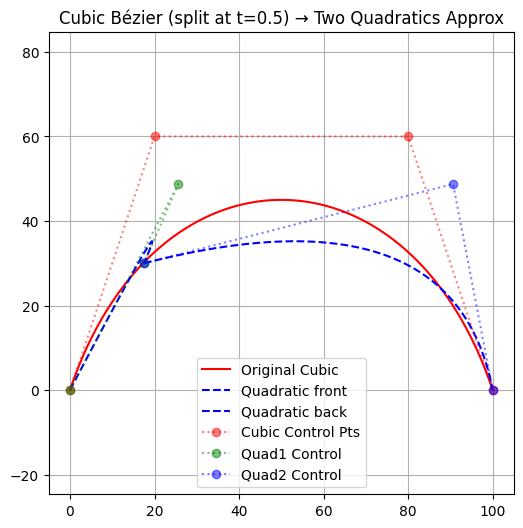

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def midpoint(p, q):
    """p, q 두 점의 중간점 반환"""
    return ((p[0]+q[0])*0.5, (p[1]+q[1])*0.5)

def de_casteljau_split_cubic(P0, P1, P2, P3):
    """
    t=0.5 지점에서 Cubic Bézier 곡선을
    '앞쪽'과 '뒤쪽' 두 개의 Cubic으로 분할
    """
    A0 = P0
    A1 = midpoint(P0, P1)
    A2 = midpoint(P1, P2)
    A3 = midpoint(P2, P3)

    B0 = midpoint(A0, A1)
    B1 = midpoint(A1, A2)
    B2 = midpoint(A2, A3)

    M  = midpoint(B0, B1)  # 중간점 (Cubic에서 t=0.5인 좌표)

    # 앞쪽 Cubic 제어점들
    C0, C1, C2, C3 = A0, A1, B1, M
    # 뒤쪽 Cubic 제어점들
    D0, D1, D2, D3 = M, B2, A3, P3

    return (C0, C1, C2, C3), (D0, D1, D2, D3)

def cubic_point(C0, C1, C2, C3, t):
    """
    3차 Bézier (C0..C3)에 대해
    파라미터 t(0~1)에서의 좌표 (x, y) 계산
    """
    u = 1.0 - t
    uu, tt = u*u, t*t
    uuu = uu*u
    ttt = tt*t

    x = uuu*C0[0] + 3*uu*t*C1[0] + 3*u*tt*C2[0] + ttt*C3[0]
    y = uuu*C0[1] + 3*uu*t*C1[1] + 3*u*tt*C2[1] + ttt*C3[1]
    return (x, y)

def approximate_cubic_by_quadratic(C0, C1, C2, C3):
    """
    하나의 Cubic (C0..C3)을
    '끝점 + 중간점(t=0.5) 일치' 방식으로 2차 Bézier로 근사.
    반환: (Q0, Q1, Q2) => Quadratic 제어점 3개
    """
    # Q0, Q2 = 양 끝점 동일
    Q0, Q2 = C0, C3

    # Cubic 중간점 (t=0.5)
    mx, my = cubic_point(C0, C1, C2, C3, 0.5)

    # Quadratic의 중간점 조건: (Q0 + 2*Q1 + Q2) / 4 = (mx, my)
    # => Q1 = 2*(mx,my) - 0.5*(Q0 + Q2)
    Q1x = 2*mx - 0.5*(Q0[0] + Q2[0])
    Q1y = 2*my - 0.5*(Q0[1] + Q2[1])
    Q1 = (Q1x, Q1y)

    return (Q0, Q1, Q2)

def sample_cubic(P0, P1, P2, P3, num=100):
    """
    Cubic Bézier (P0..P3)를 num개로 샘플링해 (x[], y[]) 반환
    """
    ts = np.linspace(0, 1, num)
    points = [cubic_point(P0, P1, P2, P3, t) for t in ts]
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    return xs, ys

def quadratic_point(Q0, Q1, Q2, t):
    """
    2차 Bézier (Q0..Q2) 파라미터 t에서 좌표 계산
    Q(t) = (1-t)^2*Q0 + 2(1-t)*t*Q1 + t^2*Q2
    """
    u = 1 - t
    x = (u*u)*Q0[0] + 2*u*t*Q1[0] + (t*t)*Q2[0]
    y = (u*u)*Q0[1] + 2*u*t*Q1[1] + (t*t)*Q2[1]
    return (x, y)

def sample_quadratic(Q0, Q1, Q2, num=100):
    """
    Quadratic Bézier (Q0..Q2)를 num개로 샘플링 (x[], y[]) 반환
    """
    ts = np.linspace(0, 1, num)
    points = [quadratic_point(Q0, Q1, Q2, t) for t in ts]
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    return xs, ys

if __name__ == "__main__":
    # ----------------------
    # 예시: Cubic Bézier 제어점 설정
    P0 = (0, 0)
    P1 = (20, 60)
    P2 = (80, 60)
    P3 = (100, 0)

    # 원본 Cubic 샘플링
    x_cubic, y_cubic = sample_cubic(P0, P1, P2, P3, num=200)

    # 1) t=0.5에서 Cubic 분할
    (C0, C1, C2, C3), (D0, D1, D2, D3) = de_casteljau_split_cubic(P0, P1, P2, P3)

    # 2) 각각을 2차 Bézier로 근사
    Q_front = approximate_cubic_by_quadratic(C0, C1, C2, C3)
    Q_back  = approximate_cubic_by_quadratic(D0, D1, D2, D3)

    # 앞쪽 Quadratic 샘플링
    x_q1, y_q1 = sample_quadratic(*Q_front, num=100)
    # 뒤쪽 Quadratic 샘플링
    x_q2, y_q2 = sample_quadratic(*Q_back, num=100)

    # -------------------------
    # 그래프 시각화
    plt.figure(figsize=(6, 6))

    # 원본 Cubic 곡선 (빨간 실선)
    plt.plot(x_cubic, y_cubic, 'r-', label='Original Cubic')

    # 근사 Quadratic: 앞쪽, 뒤쪽 (파란 점선)
    plt.plot(x_q1, y_q1, 'b--', label='Quadratic front')
    plt.plot(x_q2, y_q2, 'b--', label='Quadratic back')

    # (선택) Control Points 시각화
    # Cubic 컨트롤
    plt.plot([P0[0], P1[0], P2[0], P3[0]],
             [P0[1], P1[1], P2[1], P3[1]], 'ro:', alpha=0.5, label='Cubic Control Pts')

    # Quadratic 앞쪽 컨트롤
    plt.plot([Q_front[0][0], Q_front[1][0], Q_front[2][0]],
             [Q_front[0][1], Q_front[1][1], Q_front[2][1]],
             'go:', alpha=0.5, label='Quad1 Control')

    # Quadratic 뒤쪽 컨트롤
    plt.plot([Q_back[0][0], Q_back[1][0], Q_back[2][0]],
             [Q_back[0][1], Q_back[1][1], Q_back[2][1]],
             'bo:', alpha=0.5, label='Quad2 Control')

    plt.title("Cubic Bézier (split at t=0.5) → Two Quadratics Approx")
    plt.axis('equal')
    plt.grid(True)
    plt.legend()
    plt.show()

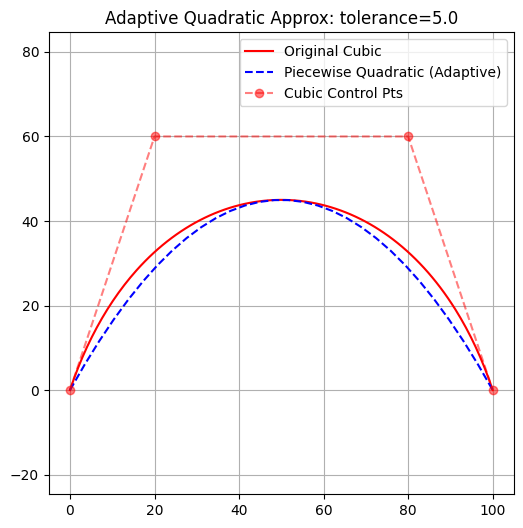

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def midpoint(p, q):
    """p, q 두 점의 중간점"""
    return ((p[0] + q[0]) * 0.5, (p[1] + q[1]) * 0.5)

def de_casteljau_split_cubic(P0, P1, P2, P3):
    """
    t=0.5에서 Cubic Bézier를
    '앞쪽'과 '뒤쪽' 두 구간으로 분할
    """
    A0 = P0
    A1 = midpoint(P0, P1)
    A2 = midpoint(P1, P2)
    A3 = midpoint(P2, P3)

    B0 = midpoint(A0, A1)
    B1 = midpoint(A1, A2)
    B2 = midpoint(A2, A3)

    M  = midpoint(B0, B1)  # 중간점(t=0.5에서의 좌표)

    # 앞쪽 Cubic
    C0, C1, C2, C3 = A0, A1, B1, M
    # 뒤쪽 Cubic
    D0, D1, D2, D3 = M, B2, A3, P3

    return (C0, C1, C2, C3), (D0, D1, D2, D3)

def cubic_point(C0, C1, C2, C3, t):
    """
    3차 Bézier (C0..C3)에서 파라미터 t(0..1)일 때 (x,y)
    B(t) = (1-t)^3*C0 + 3(1-t)^2 t*C1 + 3(1-t) t^2*C2 + t^3*C3
    """
    u = 1.0 - t
    uu, tt = u*u, t*t
    uuu = uu*u
    ttt = tt*t

    x = (uuu*C0[0] + 3*uu*t*C1[0] + 3*u*tt*C2[0] + ttt*C3[0])
    y = (uuu*C0[1] + 3*uu*t*C1[1] + 3*u*tt*C2[1] + ttt*C3[1])
    return (x, y)

def approximate_cubic_by_quadratic(C0, C1, C2, C3):
    """
    한 구간의 Cubic (C0..C3)을
    '끝점 + (t=0.5) 중간점' 일치 방식으로 2차 Bézier(Q0..Q2) 근사
    """
    # Q0, Q2 = 양 끝점
    Q0 = C0
    Q2 = C3

    # Cubic 중간점 (t=0.5)
    mid = cubic_point(C0, C1, C2, C3, 0.5)

    # (Q0 + 2*Q1 + Q2)/4 = mid => Q1 = 2*mid - 0.5*(Q0 + Q2)
    Q1x = 2*mid[0] - 0.5*(Q0[0] + Q2[0])
    Q1y = 2*mid[1] - 0.5*(Q0[1] + Q2[1])
    Q1 = (Q1x, Q1y)

    return (Q0, Q1, Q2)

def quadratic_point(Q0, Q1, Q2, t):
    """
    2차 Bézier (Q0..Q2)에서 파라미터 t(0..1)일 때 (x,y)
    Q(t) = (1-t)^2*Q0 + 2(1-t)*t*Q1 + t^2*Q2
    """
    u = 1 - t
    x = u*u*Q0[0] + 2*u*t*Q1[0] + t*t*Q2[0]
    y = u*u*Q0[1] + 2*u*t*Q1[1] + t*t*Q2[1]
    return (x, y)

def measure_approx_error(C0, C1, C2, C3, Q0, Q1, Q2, sample_steps=10):
    """
    Cubic(P0..P3) vs. Quadratic(Q0..Q2) 근사 오차 측정
    (0~1 구간을 sample_steps만큼 나누어,
    해당 t들에서의 최대 거리)
    """
    ts = np.linspace(0, 1, sample_steps)
    max_dist = 0.0
    for t in ts:
        cx, cy = cubic_point(C0, C1, C2, C3, t)
        qx, qy = quadratic_point(Q0, Q1, Q2, t)
        dist = np.hypot(cx - qx, cy - qy)
        if dist > max_dist:
            max_dist = dist
    return max_dist

def adaptive_approx_cubic(C0, C1, C2, C3, tolerance=2.0, max_depth=10, depth=0):
    """
    Adaptive Subdivision을 이용한
    Cubic -> piecewise Quadratic 근사

    1) 먼저 한 번만 Quadratic 근사
    2) 오차 측정
       - 오차 <= tolerance 이면 이대로 사용
       - 오차가 크면 t=0.5로 분할하여
         각각 재귀 호출
    3) recursion depth가 max_depth를 넘으면
       강제로 종료 (무한 분할 방지)
    """
    # 1) 먼저 단일 Quadratic 근사
    Q0, Q1, Q2 = approximate_cubic_by_quadratic(C0, C1, C2, C3)

    # 2) 오차 측정
    error = measure_approx_error(C0, C1, C2, C3, Q0, Q1, Q2, sample_steps=20)

    # 3) tolerance 검사
    if error <= tolerance or depth >= max_depth:
        # => 충분히 정확하거나, 더 못 나눌 상황
        return [(Q0, Q1, Q2)]
    else:
        # => 오차가 여전히 큼 => t=0.5로 분할
        (C0a, C1a, C2a, C3a), (C0b, C1b, C2b, C3b) = de_casteljau_split_cubic(C0, C1, C2, C3)

        # 왼쪽 구간 재귀
        left_quads  = adaptive_approx_cubic(C0a, C1a, C2a, C3a,
                                            tolerance, max_depth, depth+1)
        # 오른쪽 구간 재귀
        right_quads = adaptive_approx_cubic(C0b, C1b, C2b, C3b,
                                            tolerance, max_depth, depth+1)
        return left_quads + right_quads

def sample_piecewise_quadratics(quads, points_per_segment=20):
    """
    여러 개의 Quadratic 제어점 목록 quads = [(Q0,Q1,Q2), ...]을
    순서대로 이어붙여 x[], y[] 샘플링 반환
    """
    x_all, y_all = [], []
    for i, (Q0, Q1, Q2) in enumerate(quads):
        ts = np.linspace(0, 1, points_per_segment)
        # 인접 조각과 중복을 피하려면 첫 조각을 제외한 부분에서 t=0쪽은 스킵할 수도 있음
        # 여기서는 단순히 전부 다 이어붙입니다
        for t in ts:
            qx, qy = quadratic_point(Q0, Q1, Q2, t)
            x_all.append(qx)
            y_all.append(qy)
    return x_all, y_all

# ------------------- 데모 -------------------
if __name__ == "__main__":

    # 예시 Cubic Bézier 제어점
    P0 = (0, 0)
    P1 = (20, 60)
    P2 = (80, 60)
    P3 = (100, 0)

    # 원본 Cubic 샘플링
    def sample_cubic_points(P0, P1, P2, P3, num=200):
        ts = np.linspace(0,1,num)
        pts = [cubic_point(P0,P1,P2,P3,t) for t in ts]
        return zip(*pts)  # (x[], y[])
    x_cubic, y_cubic = sample_cubic_points(P0, P1, P2, P3, num=200)

    # -----------------------------
    # 1) Adaptive subdivision 근사
    #    tolerance를 바꿔가며 시도해볼 수 있음
    tolerance = 5.0  # 예: 오차 5 이하
    quads = adaptive_approx_cubic(P0, P1, P2, P3, tolerance=tolerance, max_depth=10)

    # 2) piecewise Quadratic으로 샘플링
    x_quad, y_quad = sample_piecewise_quadratics(quads, points_per_segment=30)

    # -----------------------------
    # 시각화
    plt.figure(figsize=(6,6))

    # 원본 Cubic(빨간색)
    plt.plot(x_cubic, y_cubic, 'r-', label='Original Cubic')

    # 근사된 piecewise Quadratic(파란색 점선)
    plt.plot(x_quad, y_quad, 'b--', label='Piecewise Quadratic (Adaptive)')

    # Cubic 제어점 표시
    plt.plot([P0[0], P1[0], P2[0], P3[0]],
             [P0[1], P1[1], P2[1], P3[1]],
             'ro--', alpha=0.5, label='Cubic Control Pts')

    plt.title(f"Adaptive Quadratic Approx: tolerance={tolerance}")
    plt.legend()
    plt.axis('equal')
    plt.grid(True)
    plt.show()


In [7]:
import torch
import torch.nn as nn

torch_data  = torch.rand(32, 256, 24, 24)
print(torch_data.shape)

torch.Size([32, 256, 24, 24])


In [8]:
torch_data = torch_data.flatten(2).permute(2,0,1)
print(torch_data.shape)


torch.Size([576, 32, 256])


In [14]:
import os 
PATH ="/home/hjp/CLO_REAL_PLEASE"



FileNotFoundError: [Errno 2] No such file or directory: './home/hjp/CLO_REAL_PLEASE'

In [9]:
import torch

num_queries = 100  # 객체 탐색을 위한 Query 개수
hidden_dim = 256   # Transformer 임베딩 차원
bs = 2             # 배치 크기

query_embed = torch.randn(num_queries, hidden_dim)  # (100, 256)

print(query_embed.unsqueeze(1).shape)
# 배치 크기만큼 확장
query_embed_expanded = query_embed.unsqueeze(1).repeat(1, bs, 1)
print(query_embed_expanded.shape)

print(query_embed.shape)           # (100, 256)
print(query_embed_expanded.shape)  # (100, 2, 256)

torch.Size([100, 1, 256])
torch.Size([100, 2, 256])
torch.Size([100, 256])
torch.Size([100, 2, 256])


In [13]:
src = torch.tensor([1.0, 2.0, 3.0])
pos = torch.tensor([0.5, -0.5, 0.2])
src_pos = src + pos

layer_norm = nn.LayerNorm(3)
output1 = layer_norm(src_pos)
output2 = layer_norm(src) + pos

In [14]:
print(output1)
print(output2)

tensor([-0.7071, -0.7071,  1.4142], grad_fn=<NativeLayerNormBackward0>)
tensor([-0.7247, -0.5000,  1.4247], grad_fn=<AddBackward0>)
